In [1]:
import os
import yaml
import numpy as np
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from gw_anomaly_detection.data.segments import SegmentInfo
from gw_anomaly_detection.data.s3_utils import S3_session
from gw_anomaly_detection.data.waveforms import Waveforms
from gw_anomaly_detection.data.process import Process


In [2]:
os.chdir('/home/chiajui/gw-anomaly-detection')
print(os.getcwd())

/home/chiajui/gw-anomaly-detection


### Loading data_config.yaml

In [3]:
with open("./data_config.yaml", "r") as file:
    config = yaml.safe_load(file)

ifos = config['data']['ifos']
data_cache = config['data']['data_cache']
asd_cache = config['data']['asd_cache']
injection = config['data']['injection']
keep_waveform = config['data']['gw_anomaly']['keep_waveform']

### Loading the information of the target segments.

In [4]:
background_segment_files = dict.fromkeys(ifos)
glitch_segment_files = dict.fromkeys(ifos)
bg_segs = dict.fromkeys(ifos)
glitch_segs = dict.fromkeys(ifos)
interval = dict.fromkeys(ifos)
bg_seg_files = {
    "H1": ["/home/chiajui/gw-anomaly-detection/segments/O3a/H1-test-1238172987-23806.segwizard"], 
    "L1":  ["/home/chiajui/gw-anomaly-detection/segments/O3a/L1-test-1238205073-23812.segwizard"],
}
for ifo in ifos:
    seg_info = SegmentInfo(ifo)
    bg_segs[ifo] = seg_info.read_segment_files(bg_seg_files[ifo])
    interval[ifo] = seg_info.whole_segment(bg_seg_files[ifo])

    print(f"Number of background segments from {ifo}: {len(bg_segs[ifo])}, interval: {interval[ifo]}.")

Number of background segments from H1: 3, interval: (1238174042, 1238183615).
Number of background segments from L1: 3, interval: (1238207182, 1238216822).


### Generating Waveform.

In [5]:
waveform = config['data']['gw_anomaly']['waveform']
qm_file = config['data']['gw_anomaly']['qm_file']
sampling_frequency = config['data']['gw_anomaly']['sampling_frequency']
length = config['data']['gw_anomaly']['length']
number = 3
wav = Waveforms(
    ifos=ifos,
    length=length,
    sampling_frequency=sampling_frequency,
)
waveforms = wav.generate_waveforms(
    waveform,
    number,
    qm_file=qm_file,
)

### Rescaling and Injection

In [6]:
flow = config['data']['processing']['flow']
fhigh = config['data']['processing']['fhigh']
resample = config['data']['processing']['resample']
crop_length = config['data']['processing']['crop_length']
target_snr_low = config['data']['gw_anomaly']['target_snr_low']
target_snr_high = config['data']['gw_anomaly']['target_snr_high']
proc = Process(
    ifos=ifos,
    data_cache=data_cache,
    asd_cache=asd_cache,
)
injected_ts, snrs = proc.inject(
    waveforms=waveforms,
    target_snr_low=target_snr_low,
    target_snr_high=target_snr_high,
    background_segments=bg_segs,
)

print(injected_ts[0]['H1'].t0)
print(injected_ts[0]['H1'].duration)
print(injected_ts[0]['H1'].sample_rate)

1238174042.9917603 s
4.0 s
16384.0 Hz


### Processing data.

In [7]:
processed_data_1 = proc.get_proccessed_data(
    timeseries=injected_ts,
    background_segments=bg_segs,
    flow=flow,
    fhigh=fhigh,
    resample=resample,
    crop_length=crop_length,
    method=1,
)
processed_data_2 = proc.get_proccessed_data(
    timeseries=injected_ts,
    background_segments=bg_segs,
    flow=flow,
    fhigh=fhigh,
    resample=resample,
    crop_length=crop_length,
    method=2,
)

In [ ]:
for i in range(number):
    # print(processed_data[i])
    for ifo in ifos:
        processed_data_1[i][ifo].write(
            f"test/{ifo}-proc_1_test_{i}.hdf5",
            format='hdf5',
        )
        processed_data_2[i][ifo].write(
            f"test/{ifo}-proc_2_test_{i}.hdf5",
            format='hdf5',
        )

H1
L1
H1
L1
H1
L1


In [11]:
ifo = "H1"
ts_1 = TimeSeries.read(f"./test/{ifo}-proc_1_test_0.hdf5", format="hdf5")
ts_2 = TimeSeries.read(f"./test/{ifo}-proc_2_test_0.hdf5", format="hdf5")

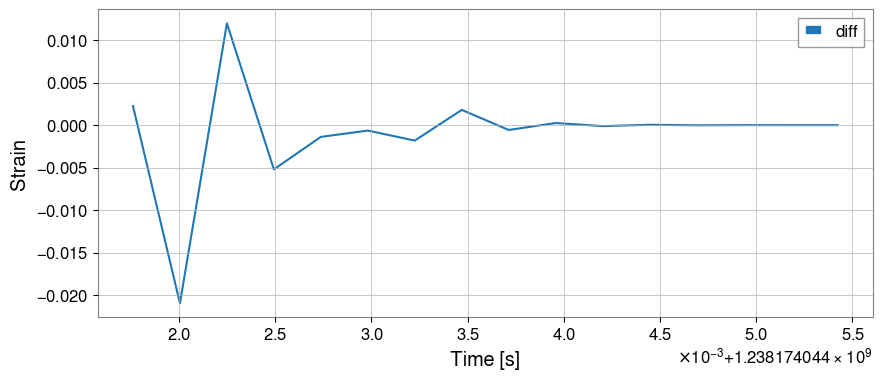

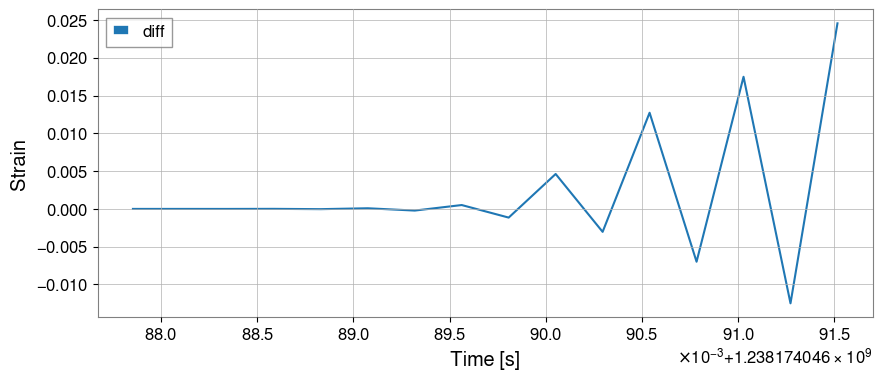

In [21]:
diff = ts_1 - ts_2
plt.figure(figsize=[10,4])
# plt.plot(ts_1.times, ts_1, label='ts_1')
# plt.plot(ts_2.times, ts_2, label='ts_2')
plt.plot(diff.times[:16], diff[:16], label='diff')
plt.xlabel("Time [s]")
plt.ylabel("Strain")
plt.legend()
plt.show()

plt.figure(figsize=[10,4])
plt.plot(diff.times[-16:], diff[-16:], label='diff')
plt.xlabel("Time [s]")
plt.ylabel("Strain")
plt.legend()
plt.show()